In [13]:
from saf_ida import *

### User-Defined Information

In [14]:
# Input directory
input_directory = './tests/user_defined/'
# Input IDA JSON filename
input_idafile = 'AAE_00002_08S_LA_08S_LADT_DF_OB_IDA_SAF_IDA_gms_T1_0.89.json'
# input grid ground motion JSON filename
input_gmfile = 'processed_GM_set_SAF_IDA_gms_T1_0.89_T1_0.89_Damp_0.05.json'

In [31]:
# output directory (can be same to the input - SAF-IDA will create a subfolder inside)
output_directory = './tests/user_defined/'

In [32]:
# Intensity measure used as predictor(s) (a list of IM name(s))
im_predictor = ['SaRatio','Ds575']

In [33]:
# If the SaRatio included as a predictor, please specify the period range ratio [a,b] --> [a*T1, b*T1]
## for collapse
saratio_period_range_col = [0.2,3.0]
## for EDP
saratio_period_range_edp = [0.2,3.0]

In [34]:
# Foundamental period T1 (sec)
T1 = 0.89

In [35]:
# Prediction target (median)
## return period (year)
return_period = [2475]
## Sa(T1) (g)
sa_t1 = [0.8]
## SaRatio
saratio = [2.0]
## duration (sec) (if included)
ds575 = [8]

In [36]:
# Prediction target (uncertainty: dispersion)
## SaRatio (if included, using non-zero)
saratio_std = [0.2]
## duration (sec) (if included, using non-zero)
ds575_std = [0.2]

In [37]:
# Prediction target (dependency: correlation coeffficient)
## correlation coefficient matrix (default is independent)
im_corrcoef = [np.identity(len(im_predictor)).tolist() for i in range(len(return_period))]

In [38]:
# Job name for this run
job_name = 'user_im_tgt'

### Create the configuration JSON file

In [39]:
import numpy as np
import os, json
# load template
with open('./examples/saf-ida_configuration_user_defined_template.json') as f:
    tmp_config = json.load(f)
# update the attributes based on user input
tmp_config['Directory']['Input'] = input_directory
tmp_config['Directory']['Output'] = output_directory
tmp_config['Training']['IDADataFile'] = input_idafile
tmp_config['Training']['IDAGMFile'] = input_gmfile
if len(saratio_period_range_col)==2:
    tmp_config['Training']['CollapseModelParam'] = {'SaRatioPeriodRange': saratio_period_range_col}
if len(saratio_period_range_edp)==2:
    tmp_config['Training']['EDPModelParam'] = {'SaRatioPeriodRange': saratio_period_range_edp}
tmp_config['Training']['IMPredictor'] = im_predictor
tmp_config['UserDefinedIM']['TargetName'] = job_name
tmp_config['UserDefinedIM']['ConditionalIntensityMeasure']['SA']['Period'] = T1
tmp_config['UserDefinedIM']['ReturnPeriods'] = return_period
tmp_std = []
tmp_config['UserDefinedIM']['InputConfig']['MeanLog'].append({'IM': 'SA', 'Value':np.log(sa_t1).tolist()})
tmp_config['UserDefinedIM']['InputConfig']['MeanLog'].append({'IM': 'SaRatio', 'Value':np.log(saratio).tolist()})
for i in range(len(return_period)):
    tmp_std.append([saratio_std[i]])
if 'Ds575' in im_predictor:
    tmp_config['UserDefinedIM']['InputConfig']['MeanLog'].append({'IM': 'Ds575', 'Value':np.log(ds575).tolist()})
    for i in range(len(return_period)):
        tmp_std[i].append(ds575_std[i])
tmp_config['UserDefinedIM']['InputConfig']['StdLog'] = tmp_std
tmp_config['UserDefinedIM']['InputConfig']['CorrelationCoeffMatrix'] = im_corrcoef
# save the configuration
job_config = os.path.join(input_directory,'saf-ida_config_{}.json'.format(job_name))
with open(job_config,'w') as f:
    json.dump(tmp_config,f,indent=2)

### SAF-IDA run

runSAF_IDA: output directory already exists.
2025-03-06 19:51:13.897301  RUNNING-MSG --NEW LOG STARTING FROM THIS LINE-- 
2025-03-06 19:51:13.908856  RUNNING-MSG SAF_IDA.get_user_defined_im: user-defined IM target configured. 
Loading structural and ground motion data.
Computing SaRatio.
SaRatio computed.
Computing SaRatio.
SaRatio computed.
Computing SaRatio.
SaRatio computed.
Data loaded.
Processing collapse data.
Collapse data processed.
Median collapse Sa (g) = [0.82091697]
Computing Sa (g) for different EDPs.
Sa (g) computed.
Computing collapse model.
Collapse model computed.
Computing EDP models.
EDP models computed.
Plotting raw collapse Sa versus IMs.


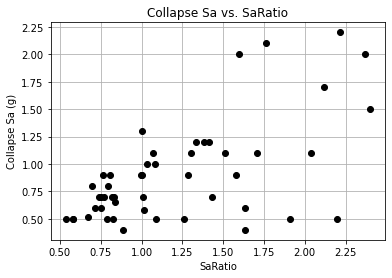

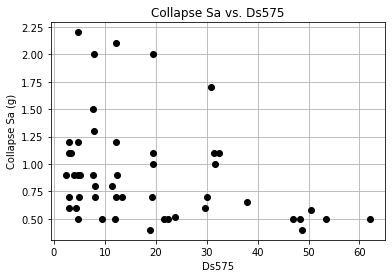

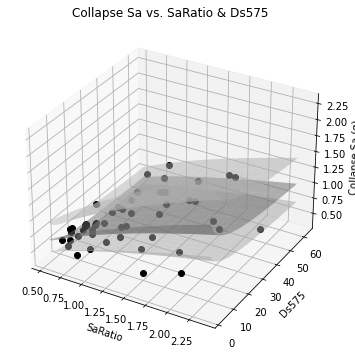

SiteInfo: site im loaded.
Collapse model received.
EDP models received.
Computing GCIM targets.
self.key_im= ['SaRatio', 'Ds575']
self.gcim[tagsite]= {'SaT1': array([0.8]), 'SaRatio': array([2.]), 'Ds575': array([8.])}
GCIM targets computed.
Adjusting EDP: SDRmax for user_im_tgt
Adjusted median of SDRmax at RP2475: 0.01237360306032861
Adjusted std of SDRmax at RP2475: 0.5906696548017313
Adjusting collapse fragility for Case: user_im_tgt


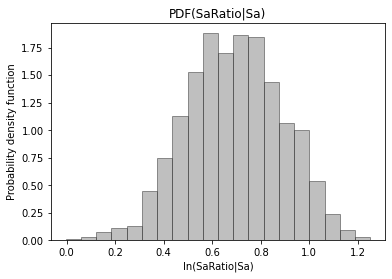

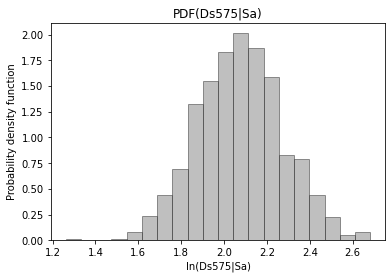

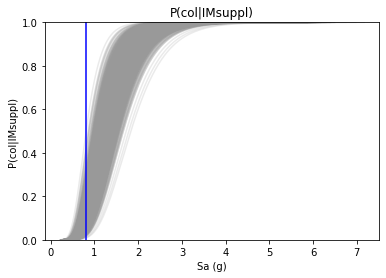

P(col|IMsuppl,Sa=0.8) =  0.11179709010855308


In [40]:
with open(job_config) as f:
    job_info = json.load(f)
# directory
dir_info = job_info['Directory']
work_dir = dir_info['Work']
input_dir = dir_info['Input']
output_dir = dir_info.get('Output',None)
if output_dir is None:
    output_dir = os.path.join(os.path.dirname(os.path.abspath(__file__),'Output'))
try:
    os.mkdir(f"{output_dir}")
except:
    print('runSAF_IDA: output directory already exists.')

# job type
job_type = job_info.get('Type', None)
if job_type is None:
    err_msg = 'run_saf_ida: Please specity "Type" in the configuraiton file.'
    saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')

# create a SAF-IDA run
saf_ida_job = SAF_IDA(dir_info=dir_info, job_name=job_name)

# configure target
if 'SiteSpecificHazard' in job_type:
    # KZ: 03/02/25 - extending this to user-defined target
    tgt_type = job_info.get('Prediction',dict()).get('TargetType','SiteSpecific')
    if tgt_type == 'SiteSpecific':
        # get the site config.
        site_config = job_info.get('SiteSpecificHazard', None)
        if site_config is None:
            err_msg = 'run_saf_ida: SiteSpecificHazard not found in job configuration.'
            saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
        # create site specific hazard information data
        saf_ida_job.get_site_specific_hazard(site_config=site_config)
    elif tgt_type in ['UserDefined','UserDefinedHazard']:
        tgt_config = job_info.get('UserDefinedHazard',None)
        if tgt_config is None:
            err_msg = 'run_saf_ida: UserDefinedHazard not found in job configuration.'
            saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
        # create user-defined hazard information data
        saf_ida_job.get_user_defined_hazard(tgt_config=tgt_config)
    elif tgt_type in ['UserDefinedIM','UserDefinedIntensityMeasure']:
        tgt_config = job_info.get('UserDefinedIM',None)
        if tgt_config is None:
            err_msg = 'run_saf_ida: UserDefinedIM not found in job configuration.'
            saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
        # create user-defined hazard information data
        saf_ida_job.get_user_defined_im(tgt_config=tgt_config)
    else:
        err_msg = 'run_saf_ida: TargetType not supported yet - please contact us.'
        saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
        
# get training config
train_config = job_info.get('Training', None)
if train_config is None:
    err_msg = 'run_saf_ida: Training not found in job configuration.'
    saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
# create a training run
saf_ida_job.model_training(input_dir=input_dir, train_config=train_config)
saf_ida_job.saf_model.plot_raw_collapse(logscale=[False,False])

# get prediction config
pred_config = job_info.get('Prediction', None)
if pred_config is None:
    err_msg = 'run_saf_ida: Prediction not found in job configuration.'
    saf_ida_job.logfile.write_msg(msg=err_msg, msg_type='ERROR')
# prediction run
saf_ida_job.model_prediction(pred_config=pred_config, output_dir=output_dir)